# 01 — Master Data Notebook
### Swiggy Instamart Strategy Case Study — Why Instamart's Path to Profitability Lags Blinkit

**Purpose of this notebook**

Every other notebook in this case study (unit economics & density, customer behavior &
monetization, competitive market structure, logistics, and the strategy simulations) reads from
`master_metrics.csv`. This notebook is the single place that **loads, validates, and documents** that
dataset, so there is exactly one source of truth and one place to check its integrity.

**Design decision: long ("tidy") format, not wide**

Swiggy, Blinkit (Eternal), and Zepto report different metrics on different bases (GOV vs.
NOV vs. NRV vs. Revenue), at different periodicities (some figures are quarterly, some are
only disclosed annually, some are one-off analyst estimates with no clean quarter attached),
and with different confidence levels (company-disclosed vs. analyst-estimated vs. derived
by back-calculation). Forcing this into one wide table (rows = quarters, columns = metrics)
would mean either fabricating numbers to fill gaps or littering the table with `NaN`. A long
table — one row per (company, segment, period, metric) observation — handles this
heterogeneity cleanly and stays easy to extend.

**Files in `data/processed/`**
- `master_metrics.csv` — the long-format dataset (loaded and integrity-checked below)
- `sources.csv` — every citation, with a short `source_id` referenced in each metric row (S01–S39)
- `data_dictionary.csv` — what each metric means and where definitions are *not* comparable across companies (still generated here)

**Real-data note:** the dataset was fact-checked against primary filings (Swiggy & Eternal
shareholder letters, Zepto UDRHP) and named analyst notes (JM Financial, Redseer, etc.). The
corrections live in `master_metrics.csv` / `sources.csv` as the hand-maintained source of truth — so
this notebook **loads and validates** them rather than regenerating from hard-coded values (which
would silently revert any correction on every run). Section 6 lists what is still missing.


In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 140)

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)
RAW.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 1. Source log

Every number in `master_metrics.csv` traces back to a `source_id` here. Where the original
filing or shareholder letter URL is known, it's used directly. Where only secondary coverage
(a news site or analyst-note summary) was available, that's marked honestly in
`primary_or_secondary` rather than implied to be a primary filing.


In [11]:
# This notebook now LOADS the validated dataset (master_metrics.csv + sources.csv) rather than
# regenerating it from hard-coded values. After the real-data fact-check, the CSVs are the
# hand-maintained source of truth — every figure was checked against primary filings (Swiggy &
# Eternal shareholder letters, Zepto UDRHP) and named analyst notes; sources.csv (S01-S39) is the
# citation registry. Loading (rather than regenerating) means re-running this notebook can never
# clobber those corrections.
sources_df = pd.read_csv(PROCESSED / "sources.csv")
n_primary = (sources_df["primary_or_secondary"].str.startswith("primary")).sum()
print(f"sources.csv loaded — {len(sources_df)} sources ({n_primary} primary / "
      f"{len(sources_df) - n_primary} secondary)")
sources_df

sources.csv loaded — 39 sources (6 primary / 33 secondary)


,source_id,org,title,url,primary_or_secondary
0,S01,Swiggy,Q2 FY2026 Shareholder Letter,https://www.swiggy.com/corporate/wp-content/uploads/2025/10/Q2-FY2026-Shareh...,primary
1,S02,Swiggy,Investor Relations — Financial Results hub,https://www.swiggy.com/corporate/investor-relations/financial-results/,primary
2,S03,Groww,Swiggy Q4 FY26 Results blog,https://groww.in/blog/swiggy-q4-fy26-results,secondary
3,S04,Storyboard18,"Swiggy Instamart expands to 1,143 dark stores, Q4 FY26",https://www.storyboard18.com/brand-marketing/swiggy-instamart-gov-jumps-69-p...,secondary
4,S05,INDmoney,"Swiggy Q4 FY26: Revenue up 45%, stock 44% below peak",https://www.indmoney.com/blog/stocks/swiggy-q4-fy26-results-stock-falling-ex...,secondary
5,S06,Whalesbook,Swiggy's Instamart Prioritizes Profit Over Growth,https://www.whalesbook.com/news/English/consumer-products/Swiggys-Instamart-...,secondary
6,S07,Whalesbook,"Swiggy Q4: Revenue jumps 45%, Instamart losses mount; Jefferies cuts target",https://www.whalesbook.com/news/English/tech/Swiggy-Q4-Revenue-Jumps-45perce...,secondary
7,S08,MarketsMojo,"Swiggy Q4 FY26: losses narrow, path to profitability uncertain",https://www.marketsmojo.com/news/result-analysis/swiggy-q4-fy26-losses-narro...,secondary
8,S09,Multibagg,"Swiggy Q4 Results FY26: loss narrows, revenue +45%",https://www.multibagg.ai/market-pulse/articles/swiggy-q4-fy26-loss-revenue-c...,secondary
9,S10,Univest,Swiggy Q4 results FY26 loss 800cr revenue 6383cr,https://univest.in/blogs/swiggy-q4-results-fy26-loss-800-crore-revenue-6383-...,secondary


## 2. Data dictionary — and where comparability breaks

This is the single most important file for not embarrassing yourself in front of an MBB
recruiter. Eternal/Blinkit reports on an **inventory model** (it owns the goods it sells, so
its topline "Revenue" includes the full retail price). Swiggy Instamart and Zepto run closer
to a **marketplace/managed-marketplace model** for most of their volume, so their topline
revenue numbers are not on the same basis as Blinkit's. **GOV (Gross Order Value), NOV (Net
Order Value), and NRV (Net Revenue Value)** are three *different* metrics used by three
different companies as their headline "size of business" number — they are related but not
identical, and treating them as interchangeable is the single easiest mistake to make with
this dataset.


In [12]:

data_dictionary = [
    dict(metric="GOV", full_name="Gross Order Value", definition="Total value of orders transacted on the platform before deductions (discounts, etc.)", comparability_note="Used by Swiggy. Roughly comparable to Blinkit's GOV in early disclosures, but Blinkit has shifted emphasis to NOV."),
    dict(metric="NOV", full_name="Net Order Value", definition="GOV net of customer-side discounts and cancellations", comparability_note="Used by both Swiggy Instamart and Blinkit in recent quarters — the more comparable cross-company metric where both report it."),
    dict(metric="NRV", full_name="Net Revenue Value", definition="Zepto's reported topline order-value metric", comparability_note="Conceptually closest to NOV but Zepto's exact deduction methodology is not fully disclosed publicly — treat NRV vs NOV comparisons as directionally indicative only."),
    dict(metric="Revenue from Operations", full_name="Statutory revenue", definition="Revenue recognized under accounting standards", comparability_note="NOT comparable across Blinkit and Swiggy/Zepto: Blinkit's inventory-led model means it recognizes the full retail sale as revenue, inflating it relative to marketplace-model peers. Do not chart Blinkit revenue next to Swiggy/Zepto revenue without this caveat."),
    dict(metric="Contribution Margin", full_name="Contribution margin (% of order value)", definition="Order economics after variable costs (delivery, packaging, etc.), before fixed overhead", comparability_note="Disclosed basis (GOV vs NOV) not always explicit in secondary coverage — verify against the actual KPI databook before using in a precise comparison."),
    dict(metric="Adjusted EBITDA Margin", full_name="Adjusted EBITDA as % of order value", definition="Company-defined non-GAAP profitability measure", comparability_note="Each company defines its own adjustments — 'Adjusted EBITDA' is not standardized across Swiggy, Blinkit, and Zepto."),
    dict(metric="AOV", full_name="Average Order Value", definition="Order value divided by number of orders", comparability_note="Comparable in spirit across companies, though the order-value basis (GOV/NOV/NRV) underneath differs."),
    dict(metric="Per Order Loss", full_name="Loss per order", definition="Total segment loss divided by order count", comparability_note="Useful cross-company comparator since it normalizes for scale — one of the cleaner comparable metrics in this dataset."),
    dict(metric="Orders per Store per Day", full_name="Daily order throughput per dark store", definition="Total orders / store count / days in period", comparability_note="Best available proxy for store-level density and capacity utilization — but watch for store age mix (a network adding many new, immature stores will show lower average throughput even if mature stores are at capacity)."),
    dict(metric="Take Rate", full_name="Platform monetization rate", definition="Adjusted revenue as % of GOV/NOV", comparability_note="Definition basis varies; treat trend direction within a company as more reliable than cross-company level comparison."),
]

data_dictionary_df = pd.DataFrame(data_dictionary)
data_dictionary_df.to_csv(PROCESSED / "data_dictionary.csv", index=False)
print(f"data_dictionary.csv written — {len(data_dictionary_df)} metric definitions")
data_dictionary_df


data_dictionary.csv written — 10 metric definitions


,metric,full_name,definition,comparability_note
0,GOV,Gross Order Value,Total value of orders transacted on the platform before deductions (discount...,"Used by Swiggy. Roughly comparable to Blinkit's GOV in early disclosures, bu..."
1,NOV,Net Order Value,GOV net of customer-side discounts and cancellations,Used by both Swiggy Instamart and Blinkit in recent quarters — the more comp...
2,NRV,Net Revenue Value,Zepto's reported topline order-value metric,Conceptually closest to NOV but Zepto's exact deduction methodology is not f...
3,Revenue from Operations,Statutory revenue,Revenue recognized under accounting standards,NOT comparable across Blinkit and Swiggy/Zepto: Blinkit's inventory-led mode...
4,Contribution Margin,Contribution margin (% of order value),"Order economics after variable costs (delivery, packaging, etc.), before fix...",Disclosed basis (GOV vs NOV) not always explicit in secondary coverage — ver...
5,Adjusted EBITDA Margin,Adjusted EBITDA as % of order value,Company-defined non-GAAP profitability measure,Each company defines its own adjustments — 'Adjusted EBITDA' is not standard...
6,AOV,Average Order Value,Order value divided by number of orders,"Comparable in spirit across companies, though the order-value basis (GOV/NOV..."
7,Per Order Loss,Loss per order,Total segment loss divided by order count,Useful cross-company comparator since it normalizes for scale — one of the c...
8,Orders per Store per Day,Daily order throughput per dark store,Total orders / store count / days in period,Best available proxy for store-level density and capacity utilization — but ...
9,Take Rate,Platform monetization rate,Adjusted revenue as % of GOV/NOV,Definition basis varies; treat trend direction within a company as more reli...


## 3. Master metrics table

Schema: `company | segment | period | period_type | metric | value | unit | yoy_pct | qoq_pct
| confidence | source_id | notes`

- **`period_type`** is one of `quarterly`, `annual`, `monthly`, or `snapshot` (a one-off
  point-in-time estimate, e.g. a market-share figure as of a specific month).
- **`confidence`** is one of `disclosed` (company-reported), `analyst_estimate` (a
  third-party research estimate), or `derived` (back-calculated by us from two disclosed
  figures — e.g. computing last quarter's margin from "improved 65 bps QoQ to X").
  `derived` rows say exactly how, in `notes`.


In [13]:
master_metrics_df = pd.read_csv(PROCESSED / "master_metrics.csv")
print(f"master_metrics.csv loaded — {len(master_metrics_df)} observations "
      f"across {master_metrics_df['company'].nunique()} companies")

# --- Data-integrity validation (replaces the old generator's implicit trust) ---
# 1) every source_id referenced in the dataset must resolve to a row in sources.csv
ref_ids = {sid.strip() for cell in master_metrics_df["source_id"].dropna()
           for sid in str(cell).split(",") if sid.strip()}
known_ids = set(sources_df["source_id"])
missing = ref_ids - known_ids
assert not missing, f"source_ids referenced but absent from sources.csv: {sorted(missing)}"

# 2) no figure should be charted twice for the same company+metric+period (a silent double-count)
dups = master_metrics_df.duplicated(subset=["company", "segment", "period", "metric"]).sum()
assert dups == 0, f"{dups} duplicate (company, segment, period, metric) observations"

# 3) confidence tags must be from the controlled vocabulary
assert set(master_metrics_df["confidence"]) <= {"disclosed", "analyst_estimate", "derived"}, \
    "unexpected confidence value"

print(f"  integrity OK — all {len(ref_ids)} referenced source_ids resolve; no duplicate observations")
print("  confidence mix: " +
      ", ".join(f"{k} {v}" for k, v in master_metrics_df["confidence"].value_counts().items()))
master_metrics_df.head(15)

master_metrics.csv loaded — 99 observations across 11 companies
  integrity OK — all 29 referenced source_ids resolve; no duplicate observations
  confidence mix: disclosed 78, analyst_estimate 14, derived 7


,row_id,company,segment,period,period_type,metric,value,unit,yoy_pct,qoq_pct,confidence,source_id,notes
0,1,Swiggy Instamart,Quick Commerce,Q4FY25,quarterly,GOV,4670.00,INR_crore,NaN,NaN,disclosed,S06,NaN
1,2,Swiggy Instamart,Quick Commerce,Q3FY26,quarterly,GOV,7938.00,INR_crore,NaN,NaN,disclosed,S06,Implied by reported sequential dip to 7881 in Q4FY26 (first-ever sequential ...
2,3,Swiggy Instamart,Quick Commerce,Q4FY26,quarterly,GOV,7881.00,INR_crore,68.8,-0.7,disclosed,"S06,S04",NaN
3,4,Swiggy Instamart,Quick Commerce,Q4FY26,quarterly,NOV,5675.00,INR_crore,60.3,4.0,disclosed,"S03,S04",NaN
4,5,Swiggy Instamart,Quick Commerce,Q4FY26,quarterly,Contribution Margin,-1.80,percent,NaN,NaN,disclosed,"S03,S04",Improved 65 bps sequentially from Q3FY26; basis (GOV vs NOV) not explicit in...
5,6,Swiggy Instamart,Quick Commerce,Mar2026,monthly,Contribution Margin,-1.10,percent,NaN,NaN,disclosed,"S03,S04",NaN
6,7,Swiggy Instamart,Quick Commerce,Q3FY26,quarterly,Contribution Margin,-2.45,percent,NaN,NaN,derived,NaN,Back-calculated: Q4FY26 value (-1.8%) minus the stated +65bps sequential imp...
7,8,Swiggy Instamart,Quick Commerce,Q4FY26,quarterly,Adjusted EBITDA,-858.00,INR_crore,NaN,NaN,disclosed,S07,NaN
8,9,Swiggy Instamart,Quick Commerce,Q4FY26,quarterly,Adjusted EBITDA Margin,-10.90,percent,NaN,NaN,disclosed,S03,NaN
9,10,Swiggy Instamart,Quick Commerce,Q3FY26,quarterly,Adjusted EBITDA Margin,-11.40,percent,NaN,NaN,disclosed,S03,NaN


## 4. Data completeness check

Before building anything on top of this, it's worth seeing exactly where the holes are —
which company/segment combinations have rich quarterly history versus a handful of
snapshot estimates.


In [14]:

coverage = (master_metrics_df
            .groupby(["company", "confidence"])
            .size()
            .unstack(fill_value=0))

coverage = coverage[[c for c in ["disclosed", "derived", "analyst_estimate"] if c in coverage.columns]]
coverage


confidence,disclosed,derived,analyst_estimate
company,,,
Amazon Now,1,0,0
Blinkit,19,1,4
Flipkart Minutes,0,0,1
Industry,0,0,1
JioMart,1,0,0
Swiggy Consolidated,18,0,1
Swiggy Food Delivery,8,3,0
Swiggy Instamart,19,2,5
Swiggy OOH,2,0,0


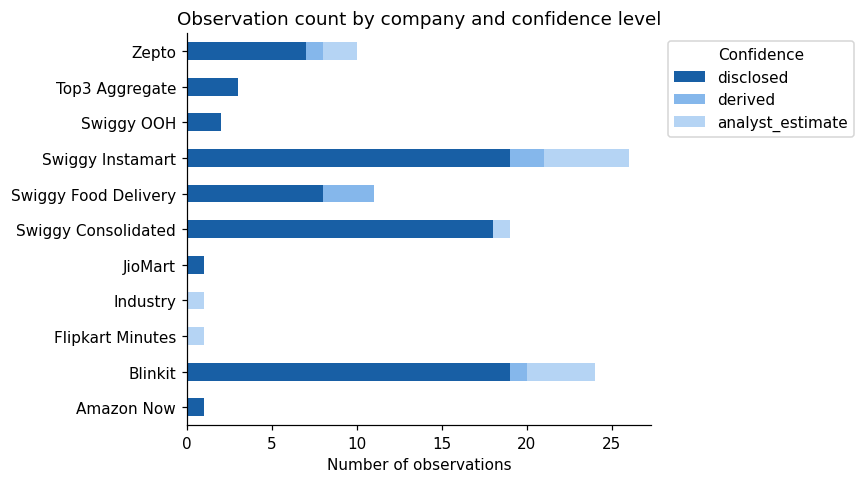

In [15]:

fig, ax = plt.subplots(figsize=(8, 4.5))
coverage.plot(kind="barh", stacked=True, ax=ax,
              color={"disclosed": "#185FA5", "derived": "#85B7EB", "analyst_estimate": "#B5D4F4"})
ax.set_xlabel("Number of observations")
ax.set_ylabel("")
ax.set_title("Observation count by company and confidence level")
ax.legend(title="Confidence", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(PROCESSED / "chart_data_coverage.png", bbox_inches="tight")
plt.show()


## 5. Three illustrative cross-player charts

These are quick sanity-check charts to confirm the dataset is usable end to end — the real
analytical charts belong in the branch notebooks. Each one pulls straight from
`master_metrics_df`, which is the pattern every downstream notebook should follow.


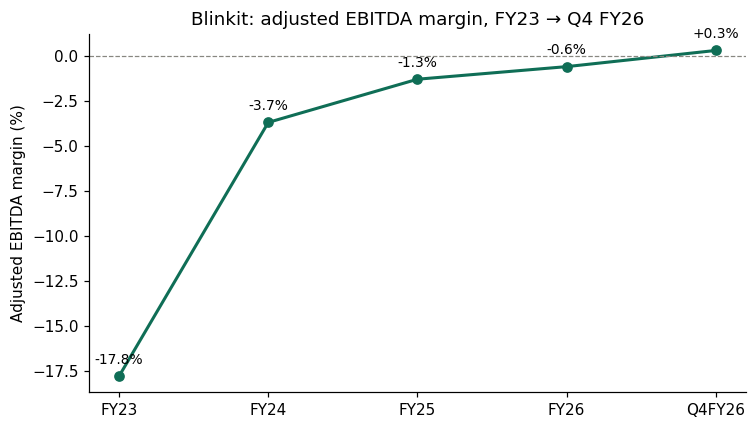

In [16]:

# Chart 1 — Blinkit's annual EBITDA margin trajectory FY23 -> Q4FY26, the clearest
# "this is achievable" reference line for the whole case study.
blinkit_margin = master_metrics_df[
    (master_metrics_df.company == "Blinkit") &
    (master_metrics_df.metric == "Adjusted EBITDA Margin")
].copy()

# enforce a sensible chronological order
order = ["FY23", "FY24", "FY25", "FY26", "Q4FY26"]
blinkit_margin["period"] = pd.Categorical(blinkit_margin["period"], categories=order, ordered=True)
blinkit_margin = blinkit_margin.sort_values("period")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(blinkit_margin["period"].astype(str), blinkit_margin["value"], marker="o",
        color="#0F6E56", linewidth=2)
ax.axhline(0, color="#888780", linewidth=0.8, linestyle="--")
ax.set_ylabel("Adjusted EBITDA margin (%)")
ax.set_title("Blinkit: adjusted EBITDA margin, FY23 \u2192 Q4 FY26")
for x, y in zip(blinkit_margin["period"].astype(str), blinkit_margin["value"]):
    ax.annotate(f"{y:+.1f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(PROCESSED / "chart_blinkit_margin_trajectory.png", bbox_inches="tight")
plt.show()


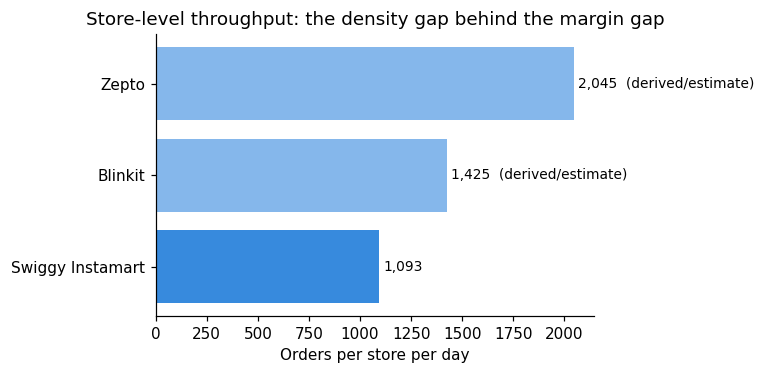

In [17]:

# Chart 2 — Orders per store per day, cross-player density comparison.
density = master_metrics_df[master_metrics_df.metric == "Orders per Store per Day"].copy()
density = density.sort_values("value")

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["#378ADD" if c == "disclosed" else "#85B7EB" for c in density["confidence"]]
ax.barh(density["company"], density["value"], color=colors)
for y, (val, conf) in enumerate(zip(density["value"], density["confidence"])):
    suffix = "" if conf == "disclosed" else "  (derived/estimate)"
    ax.text(val + 20, y, f"{val:,.0f}{suffix}", va="center", fontsize=9)
ax.set_xlabel("Orders per store per day")
ax.set_title("Store-level throughput: the density gap behind the margin gap")
plt.tight_layout()
plt.savefig(PROCESSED / "chart_density_comparison.png", bbox_inches="tight")
plt.show()


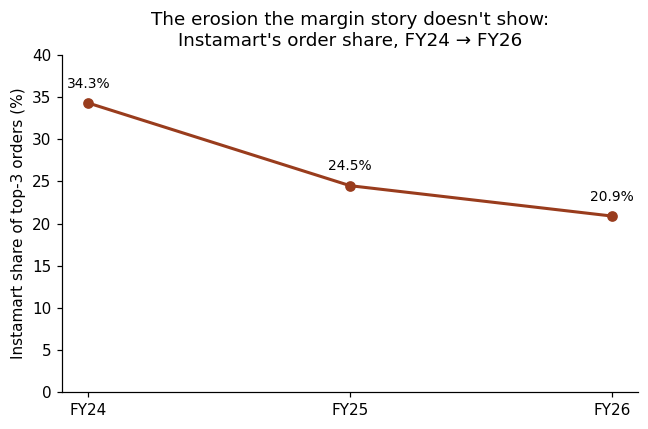

In [18]:

# Chart 3 — Instamart's order-share erosion among the top 3 players, FY24 -> FY26.
share = master_metrics_df[master_metrics_df.metric == "Instamart Order Share (of Top 3)"].copy()
share["period"] = pd.Categorical(share["period"], categories=["FY24", "FY25", "FY26"], ordered=True)
share = share.sort_values("period")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(share["period"].astype(str), share["value"], marker="o", color="#993C1D", linewidth=2)
ax.set_ylabel("Instamart share of top-3 orders (%)")
ax.set_title("The erosion the margin story doesn't show:\nInstamart's order share, FY24 \u2192 FY26")
ax.set_ylim(0, 40)
for x, y in zip(share["period"].astype(str), share["value"]):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(PROCESSED / "chart_order_share_erosion.png", bbox_inches="tight")
plt.show()


## 6. Known gaps — what to fetch next to strengthen this dataset

This scaffold is enough to start the branch notebooks, but these gaps will limit how
rigorous the contribution-margin and density regressions in Branch 1 can be:

1. **Instamart's full quarterly contribution-margin history, Q1 FY25 through Q2 FY26.**
   Only Q3 FY26, Q4 FY26, and the March 2026 monthly figure are captured here. The actual
   numbers live in Swiggy's KPI databooks at
   `swiggy.com/corporate/investor-relations/financial-results/` — pull the databook PDF or
   XLS for each quarter rather than relying on secondary press summaries.
2. **Blinkit's quarterly (not just annual) GOV/NOV series for FY24-FY26.** Currently only
   two quarterly data points (Q4 FY25, Q4 FY26) plus the annual margin trend. Eternal's
   investor relations page publishes this on the same quarterly cadence as Swiggy.
3. **A verified Zepto UDRHP citation.** Several Zepto figures here (order share, NRV,
   advertising revenue) are sourced through secondary press coverage that cites the UDRHP
   without a direct link. If Zepto's IPO documents are public by the time this is finalized,
   replace `S19` with the actual filing.
4. **Orders-per-store-per-day for Blinkit and Zepto are currently derived/estimated**, not
   disclosed. If either company publishes this directly in a future shareholder letter,
   replace the derived row in `master_metrics.csv`.
5. **A consistent MTU (monthly transacting users) series for Instamart specifically.**
   Swiggy discloses MTU prominently at the consolidated/food-delivery level; the Instamart-only
   figure used here is a secondary citation and should be double-checked against the KPI
   databook.

**Pattern for every downstream notebook:**
```python
import pandas as pd
df = pd.read_csv("../data/processed/master_metrics.csv")
instamart_margin = df[(df.company == "Swiggy Instamart") & (df.metric == "Contribution Margin")]
```
